In [1]:
# Import Libraries
import rawpy as rp
import cv2
import numpy as np
from numpy import asarray
import pandas as pd
from scipy.signal import savgol_filter

import flat_field #custom
import Curvature #custom

import PIL
from PIL import Image
from PIL.ExifTags import TAGS
import exiftool
import notebook

from pathlib import Path 
import glob
import os
import sys

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import warnings
warnings.filterwarnings('ignore')

In [2]:
path = 'Stacking_Database/*.dng'

In [3]:
raw_img = []
for img in glob.glob(path):
    n= rp.imread(img)
    raw_img.append(n)

In [4]:
bayer = []
for i in raw_img:
    bayer.append(i.raw_image)
    
raw_arr = []
for i in bayer:
    raw_arr.append(asarray(i))
    
avg = np.mean(raw_arr, axis=0).astype(int)

In [5]:
def extract_green_planes(bayer_img):
    """
    Extract the two green planes from an RGGB Bayer image.
    Returns (G1, G2) as NumPy arrays.
    """
    # G1: even rows, odd columns
    g1 = bayer_img[0::2, 1::2]

    # G2: odd rows, even columns
    g2 = bayer_img[1::2, 0::2]

    return g1, g2

green1_ave, green2_ave = extract_green_planes(avg)

green_ave = np.rint((green1_ave + green2_ave) / 2).astype(np.int16)

In [6]:
def green_average_from_bayer(bayer_img, out_dtype=np.int16):
    g1, g2 = extract_green_planes(bayer_img)
    return np.rint((g1 + g2) / 2).astype(out_dtype)

# raw_arr is a list (or array) of 5 bayer frames, each (H, W)
green_arr = np.stack([green_average_from_bayer(frame) for frame in raw_arr], axis=0)

In [7]:
w1, w2 = 400, 400
x1, y1, wx1, wy1 = 790, 550, w1, w2

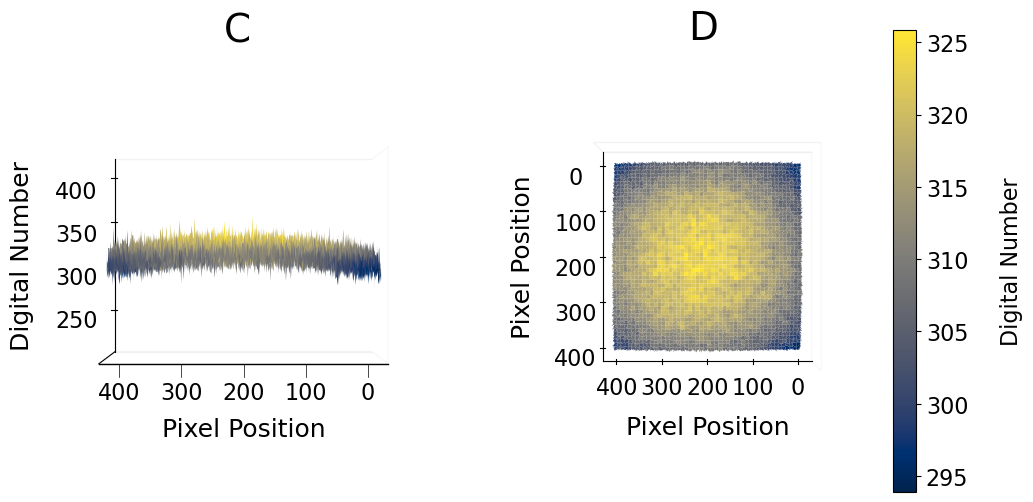

In [8]:
flat_field.flat_field(green_ave[y1:y1+wy1, x1:x1+wx1], 'C', 'D', 'uniformity_stack.png')

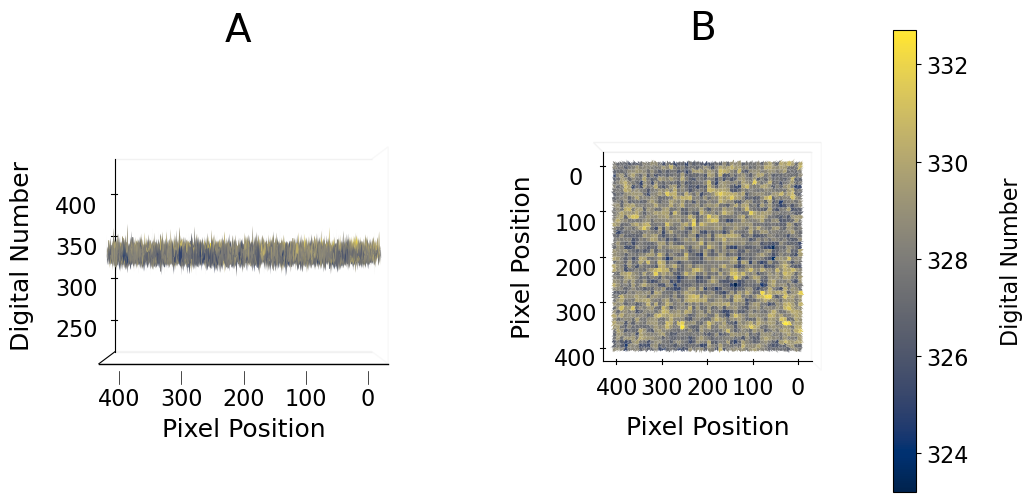

In [9]:
# Quantify Curvature, Banding, and High-Frequency Noise Quantified

H, W = green_ave[y1:y1+wy1, x1:x1+wx1].shape
mean_dn = green_ave[y1:y1+wy1, x1:x1+wx1].mean()

# --- CURVATURE (2-D low-frequency illumination gradient): quadratic surface fit ---
# z(x,y) = c0 + c1*x + c2*y + c3*x^2 + c4*x*y + c5*y^2

yy, xx = np.mgrid[0:H, 0:W]  # yy: rows, xx: cols

A = np.column_stack([
    np.ones(H * W),
    xx.ravel(),
    yy.ravel(),
    (xx**2).ravel(),
    (xx * yy).ravel(),
    (yy**2).ravel()
])

b = green_ave[y1:y1+wy1, x1:x1+wx1].ravel()

coef, *_ = np.linalg.lstsq(A, b, rcond=None)

curv_field = (coef[0]
              + coef[1] * xx + coef[2] * yy
              + coef[3] * xx**2 + coef[4] * xx * yy + coef[5] * yy**2)

# Detrend while preserving overall brightness, then shift for visualization 
resid = green_ave[y1:y1+wy1, x1:x1+wx1] - curv_field
ave_im_detrended = (resid - resid.min())+300

# Keep using the existing plotting / flat-field visualization
flat_field.flat_field(ave_im_detrended, 'A', 'B', 'uncurved_ave.png')

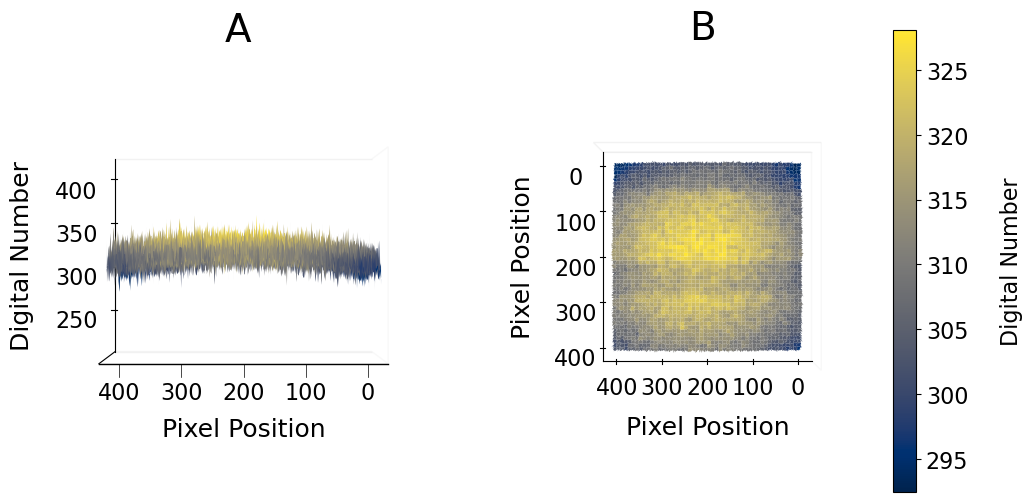

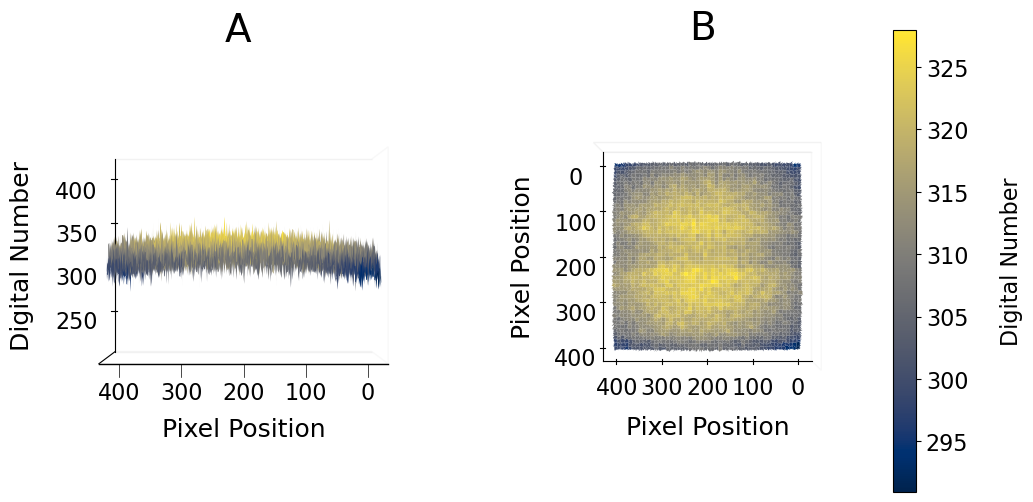

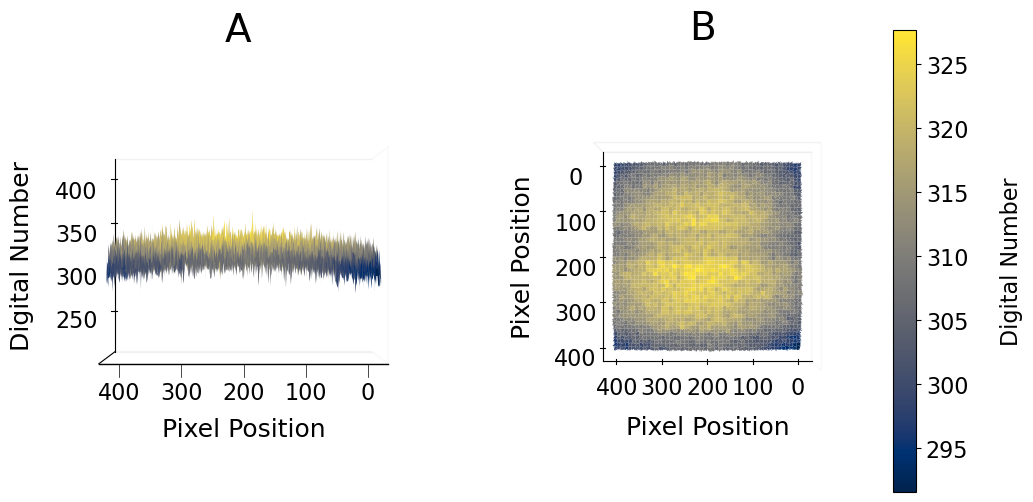

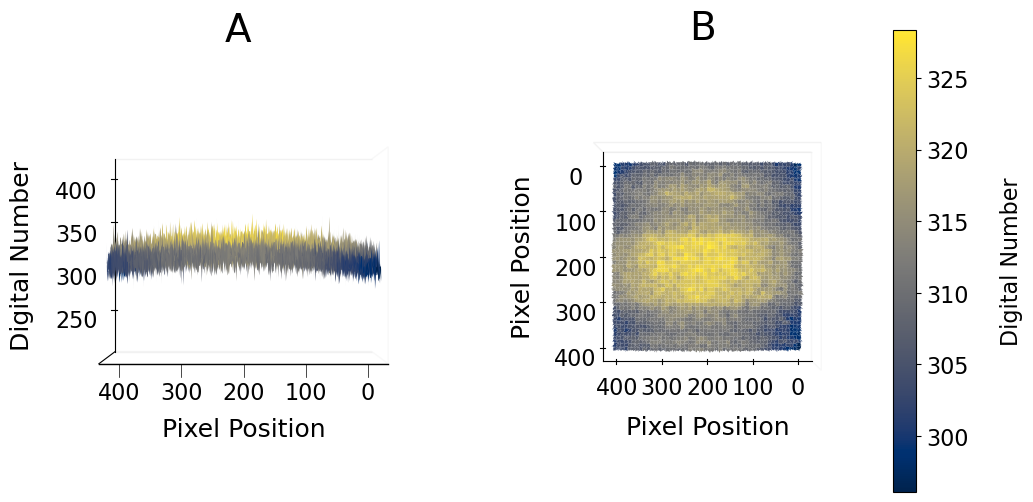

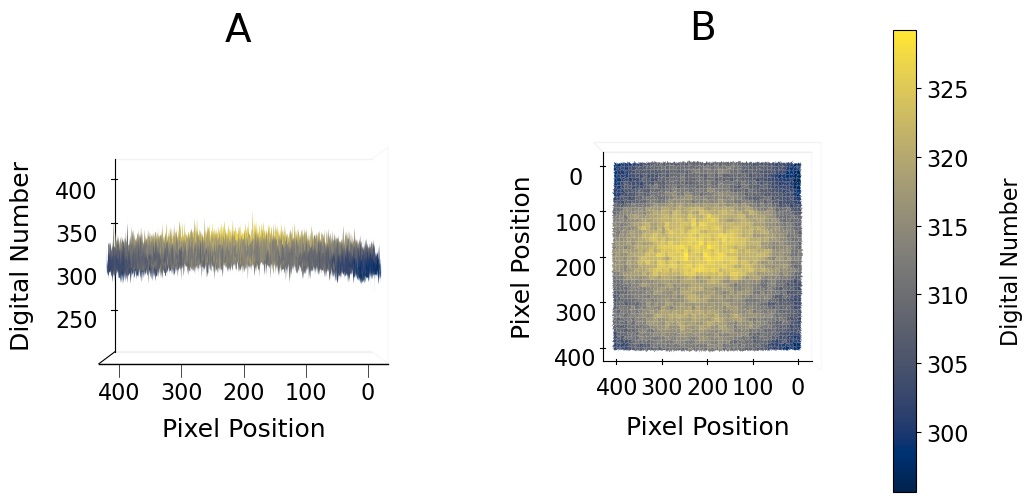

In [10]:
for i, frame in enumerate(green_arr):
    roi = frame[y1:y1+wy1, x1:x1+wx1]
    flat_field.flat_field(
        roi,
        'A',
        'B',
        f'uniformity_stack_individual_{i}.png'
    )

In [11]:
def precompute_quadratic_design(H, W):
    yy, xx = np.mgrid[0:H, 0:W]
    A = np.column_stack([
        np.ones(H * W),
        xx.ravel(),
        yy.ravel(),
        (xx**2).ravel(),
        (xx * yy).ravel(),
        (yy**2).ravel()
    ])
    return A, xx, yy

def flatten_frame_quadratic(img2d, A):
    """
    Fit quadratic surface to img2d and subtract it.
    Returns:
      curv_field (2D), resid (2D), flat_preserve_mean (2D)
    """
    H, W = img2d.shape
    b = img2d.astype(np.float64).ravel()
    coef, *_ = np.linalg.lstsq(A, b, rcond=None)

    # Reconstruct fitted field efficiently
    curv_field = (A @ coef).reshape(H, W)

    resid = img2d.astype(np.float64) - curv_field
    flat_preserve_mean = resid + img2d.mean()   # keeps same mean as original ROI

    return curv_field, resid, flat_preserve_mean

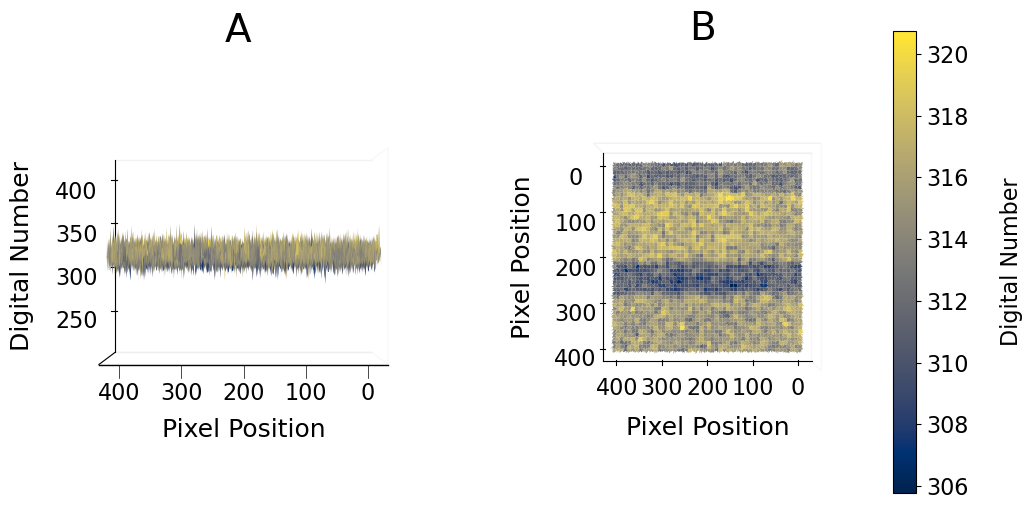

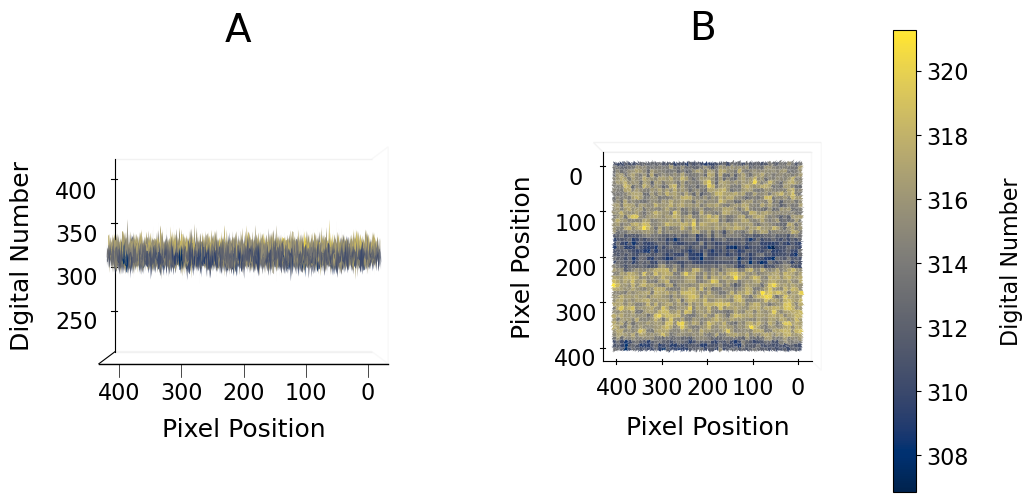

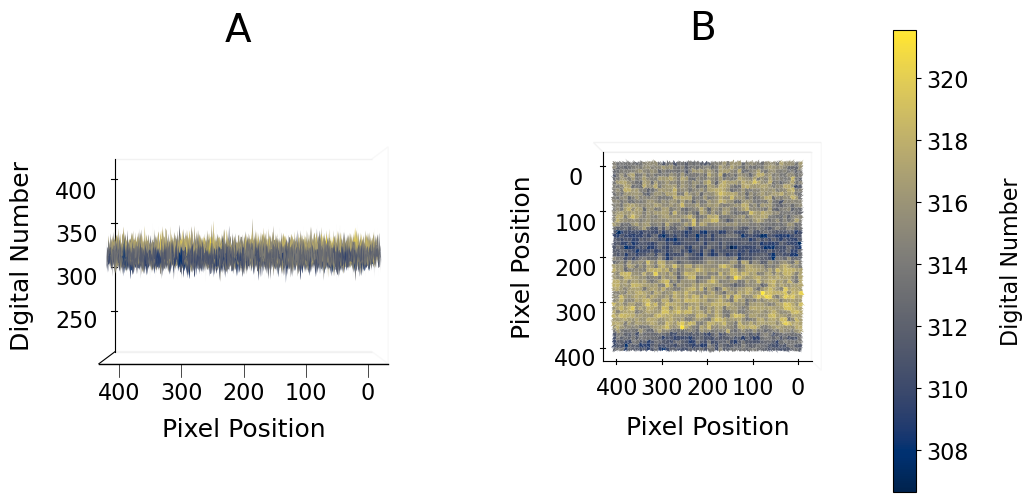

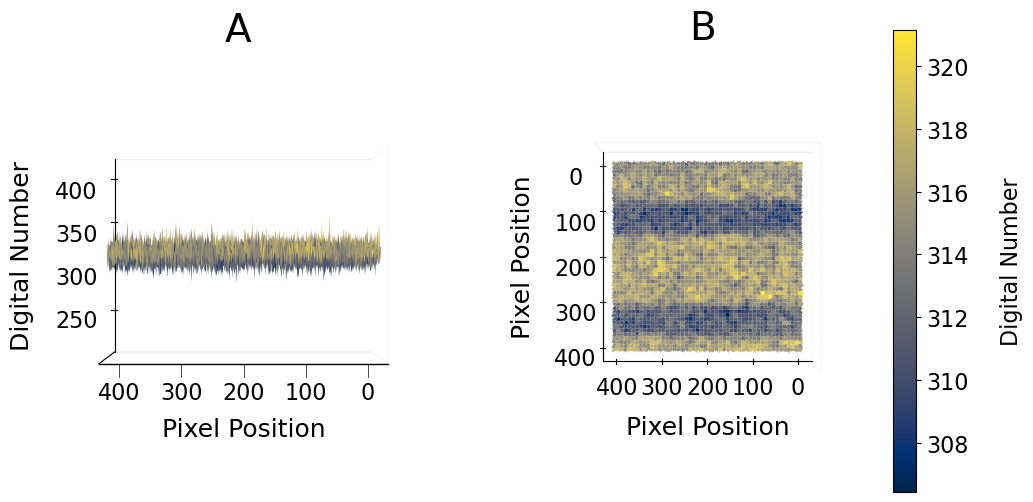

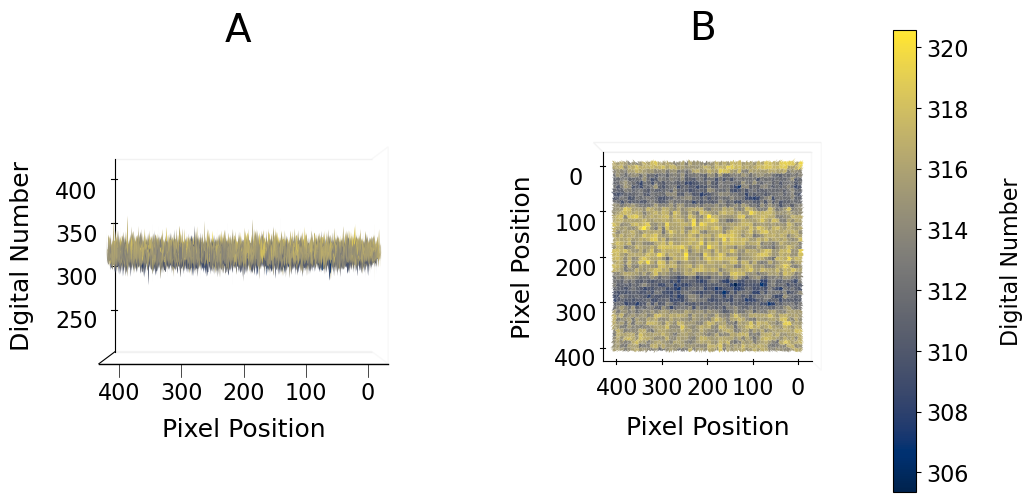

In [12]:
# Build ROI stack: (N, H, W)
roi_stack = green_arr[:, y1:y1+wy1, x1:x1+wx1]
N, H, W = roi_stack.shape

A, xx, yy = precompute_quadratic_design(H, W)

flat_stack = np.empty_like(roi_stack, dtype=np.float64)
resid_stack = np.empty_like(roi_stack, dtype=np.float64)

for i in range(N):
    curv_field, resid, flat = flatten_frame_quadratic(roi_stack[i], A)
    resid_stack[i] = resid
    flat_stack[i] = flat

    # optional: save a plot per frame
    flat_field.flat_field(flat, 'A', 'B', f'uncurved_{i}.png')

In [13]:
def estimate_row_banding_from_stack(
    green_arr_det,
    x0=50,
    x1=350,
    sg_window=61,
    sg_poly=2
):
    """
    Estimate horizontal banding as a per-row offset using
    robust statistics across columns and frames.
    """
    row_profiles = []

    for k in range(green_arr_det.shape[0]):
        Rk = green_arr_det[k]
        row_profiles.append(
            np.median(Rk[:, x0:x1], axis=1)
        )

    row_profiles = np.stack(row_profiles, axis=0)   # (5, 400)
    row_med = np.median(row_profiles, axis=0)       # (400,)

    # smooth to isolate mid-frequency banding
    row_smooth = savgol_filter(
        row_med,
        window_length=sg_window,
        polyorder=sg_poly,
        mode="interp"
    )

    # zero-mean so we don't shift DN
    band = row_smooth - np.median(row_smooth)

    return band   # shape (400,)


In [14]:
band = estimate_row_banding_from_stack(resid_stack, x0=50, x1=350)

green_ave_debanded = ave_im_detrended - band[:, None]


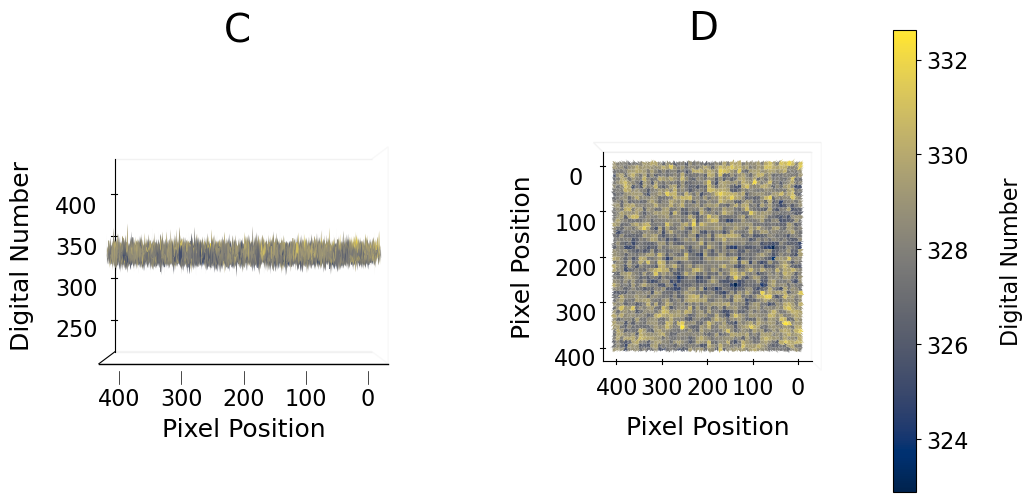

In [15]:
flat_field.flat_field(green_ave_debanded, 'C', 'D', 'debanded.png')

In [16]:
margin = 100
x0, x1 = margin, green_ave_debanded.shape[1] - margin


In [17]:
hf_resid = green_ave_debanded[:, x0:x1].ravel()


In [18]:
med = np.median(hf_resid)
mad = np.median(np.abs(hf_resid - med))
sigma_hf = 1.4826 * mad

print(f"HF noise (robust σ): {sigma_hf:.3f} DN")


HF noise (robust σ): 7.267 DN


In [19]:
mu = np.mean(hf_resid)
sigma_rms = np.sqrt(np.mean((hf_resid - mu)**2))

print(f"HF noise (RMS): {sigma_rms:.3f} DN")


HF noise (RMS): 7.258 DN


In [20]:
# compute HF noise from a SINGLE detrended, debanded frame
single_resid = resid_stack[0] - band[:, None]
hf_single = single_resid[:, x0:x1].ravel()

mad_single = np.median(np.abs(hf_single - np.median(hf_single)))
sigma_single = 1.4826 * mad_single
print("Single-frame HF DN:", sigma_single)


Single-frame HF DN: 8.441176284809115


In [21]:
WIN = 30
HALF = WIN // 2
MARGIN = 100

centers = {
    "left_lower":  (MARGIN, MARGIN),
    "right_lower": (400 - MARGIN, MARGIN),
    "center":      (200, 200),
    "left_upper":  (MARGIN, 400 - MARGIN),
    "right_upper": (400 - MARGIN, 400 - MARGIN),
}

def window_slices(cx, cy, win=30):
    half = win // 2
    x0, x1 = cx - half, cx + half
    y0, y1 = cy - half, cy + half
    return slice(y0, y1), slice(x0, x1)   # note: [y, x]


In [22]:
# deband each detrended frame (stack)
debanded_stack = resid_stack - band[None, :, None]   # (5,400,400)

# and the debanded 5-frame average image (if you want it)
debanded_ave = debanded_stack.mean(axis=0)           # (400,400)


In [23]:
def masked_mean(im2d, centers_dict, win=30):
    vals = []
    for name, (cx, cy) in centers_dict.items():
        ys, xs = window_slices(cx, cy, win)
        vals.append(im2d[ys, xs].mean())
    return np.mean(vals), np.array(vals)  # overall mean, plus the 5 window means


In [24]:
frame_means = []
frame_window_means = []

for k in range(debanded_stack.shape[0]):
    m, v = masked_mean(debanded_stack[k], centers, win=WIN)
    frame_means.append(m)
    frame_window_means.append(v)

frame_means = np.array(frame_means)                 # (5,)
frame_window_means = np.stack(frame_window_means)   # (5 frames, 5 windows)

print("Per-frame masked DN:", frame_means)
print("Mean DN:", frame_means.mean())


Per-frame masked DN: [ 1.55157304  0.48485975  0.90242525 -0.97955087 -0.26867912]
Mean DN: 0.3381256103416749


In [25]:
sigma_std = frame_means.std(ddof=1)

med = np.median(frame_means)
mad = np.median(np.abs(frame_means - med))
sigma_mad = 1.4826 * mad

print(f"Noise of masked DN (std): {sigma_std:.3f} DN")
print(f"Noise of masked DN (MAD→σ): {sigma_mad:.3f} DN")


Noise of masked DN (std): 0.990 DN
Noise of masked DN (MAD→σ): 1.117 DN


In [26]:
# For each frame: std across the 5 windows
within_frame_spatial_std = frame_window_means.std(axis=1, ddof=1)
print("Within-frame spatial std (5 windows) per frame:", within_frame_spatial_std)
print("Mean within-frame spatial std:", within_frame_spatial_std.mean())


Within-frame spatial std (5 windows) per frame: [0.84648392 2.24960346 1.57657813 2.39750692 2.51109547]
Mean within-frame spatial std: 1.9162535786287602


In [27]:
stack_dn, stack_windows = masked_mean(debanded_ave, centers, win=WIN)
print("Masked DN on 5-frame average image:", stack_dn)
print("Window means on stacked image:", stack_windows)


Masked DN on 5-frame average image: 0.3381256103416748
Window means on stacked image: [0.14948174 0.82222748 0.04605968 0.57297302 0.09988613]
